In [40]:
import numpy as np
import jax.numpy as jnp
import jax
import equinox as eqx
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import immunowave as iw
from immunowave_paper_utils import style_axes, colors, fontsize, linewidth, rc_params
import diffrax as dx
from diffrax import SaveAt
import math
import pickle
import os
jax.config.update("jax_enable_x64", True)

In [2]:
linewidth = 3
fontsize = 24
markersize = 12
markeredgewidth = 2
rc_params["axes.linewidth"] = linewidth
rc_params["font.size"] = fontsize
mpl.rcParams.update(rc_params)
mpl.rcParams["pdf.fonttype"] = 42
sim_color = np.array([94, 45, 144]) / 255

In [38]:
savedir = r"/home/brandon/Documents/Code/immunowave/data/2025_11_11-delayed_autoactivation"

### Define model

In [4]:
class State(iw.State):
    u: iw.ScalarField
    w: iw.ScalarField

To account for time delay in auto-activation, we consider the activation of $u$ to be mediated through an intermediate factor, $w$, which represents internal signaling components within each cell. In dimensionless form, this model is governed by
$$
\partial_t u = \nabla^2 u + f(u, w) + 2 I \delta(\vec{x})
$$

$$
\partial_t w = \epsilon(u - w)
$$

where
$$
f(u, w) = \frac{w^n}{K^n_D + w^n} - u
$$
with $I, K_D > 0$, and $n > 1$.


In [5]:
class Model(iw.Model):
    KD: float
    n: float
    I: float
    ϵ: float = 1.0
    # Bandwidth adjustment for Dirac delta approximation (grid units)
    bw_adjust: float = 0.5

    def f(self, u, w):
        KD, n = self.KD, self.n
        return w.hill(KD, n) - u

    def delta(self, u):
        """Helper function to approximate a Dirac delta as a Gaussian on the same grid as u."""
        σ = self.bw_adjust * u.h

        def gaussian(*coords):
            squared_dist = sum(coord**2 for coord in coords)
            return jnp.exp(-squared_dist / (2 * σ**2))

        result = iw.ScalarField(u.values.shape, u.lb, u.h, fn=gaussian)
        result /= result.integral()
        return result

    def __call__(self, t, state: State, args=None):
        u = state.u
        w = state.w
        Δu = u.laplacian(bc="neumann")
        f = self.f
        I = self.I
        δ = self.delta(u)
        ϵ = self.ϵ

        dudt = Δu + f(u, w) + 2 * I * δ
        dwdt = ϵ * (u - w)

        return State(dudt, dwdt)

### Analytical $I_c$

In dimensionless units, for $K_D\ll1$, the unstable fixed point is approximately $u_1 \approx K^{n/(n-1)}_D$, and the critical stimulus is
$$
I_c \approx \sqrt{\frac{n-1}{n+1}}\,u_1
$$


In [6]:
def u1(KD, n):
    return KD ** (n / (n - 1))


def Ic(KD, n):
    return ((n - 1) / (n + 1)) ** 0.5 * u1(KD, n)

In [7]:
L = 20.0
lb = [-L / 2]
n_spatial = 200
shape = (n_spatial,)
h = L / (n_spatial - 1)

state = State(u=iw.ScalarField(shape, lb, h, 0), w=iw.ScalarField(shape, lb, h, 0))

In [9]:
KD = 0.01
n = 4.0

In [10]:
t0 = 0.0
t1 = jnp.inf


@jax.jit
def norm(state: State):
    d = state.u.ndim
    L = state.u.ub[0] - state.u.lb[0]  # Length of the domain in first dimension
    # indicator function for middle of the domain
    ind = iw.ScalarField(
        state.u.values.shape,
        state.u.lb,
        state.u.h,
        fn=lambda *coords: jnp.where(
            sum(abs(coord) ** d for coord in coords) ** (1 / d) < L / 4, 1.0, 0.0
        ),
    )
    return (ind * state.u).integral() / ind.integral()


steady_state_event = dx.Event(dx.steady_state_event(atol=0, rtol=1e-3, norm=norm))

In [11]:
kwargs = dict(
    dt0=1e-4,
    max_steps=10000000,
    atol=1e-8,
    rtol=1e-8,
    throw=True,
    event=steady_state_event,
)

## Run one simulation

In [29]:
model= Model(KD=KD, n=n, I=0.001, ϵ=0.1)
res = iw.solve(model, state, 0, 20, **kwargs)

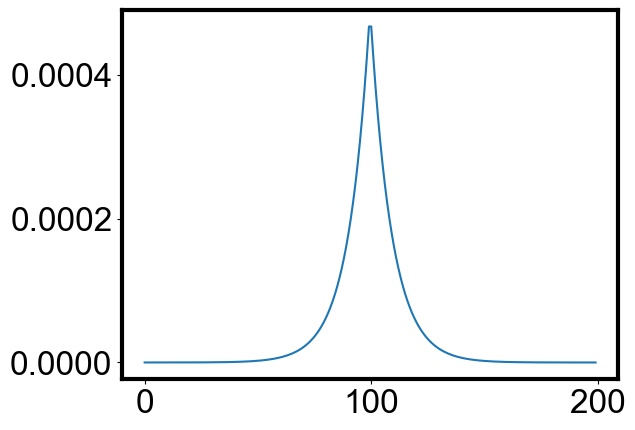

In [31]:
plt.figure()
plt.plot(res.ys.w.values[0])

## Run to steady state and compute final mean activation

In [32]:
@jax.jit
def mean_activation(model, state):
    steady_state = iw.solve(model, state, 0, jnp.inf, **kwargs).ys.u.map(jnp.squeeze)
    area = math.prod(ub - lb for ub, lb in zip(state.u.ub, state.u.lb))
    return steady_state.integral() / area

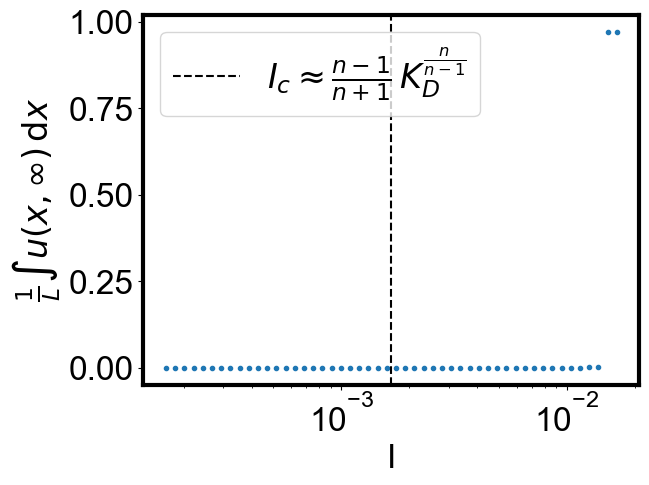

In [33]:
I_grid = jnp.geomspace(0.1 * Ic(KD, n), 10 * Ic(KD, n), 50)
models = [Model(KD=KD, n=n, I=I, ϵ=0.01) for I in I_grid]

plt.plot(I_grid, [mean_activation(model, state) for model in models], ".")
plt.axvline(
    Ic(KD, n),
    color="k",
    linestyle="--",
    label=r"$I_c \approx \frac{n-1}{n+1}\,K^\frac{n}{n-1}_D$",
)
plt.legend()
plt.xlabel("I")
plt.ylabel(r"$\frac{1}{L} \int u(x, \infty) \, \mathrm{d}x$")
plt.xscale("log")
plt.show()

In [34]:
def find_Ic(model, state, tolerance=1e-4, max_iterations=20, verbose=False):
    _print = print if verbose else lambda *args, **kwargs: None
    # initial bounds
    model_low = eqx.tree_at(lambda m: m.I, model, 0.9 * model.I)
    model_high = eqx.tree_at(lambda m: m.I, model, 1.1 * model.I)
    # If low bound doesn't give low activation, reduce it
    while mean_activation(model_low, state) > 0.5:
        _print("decreasing invalid lower bound")
        model_low = eqx.tree_at(lambda m: m.I, model_low, model_low.I / 2)
    # If high bound doesn't give high activation, increase it
    while mean_activation(model_high, state) < 0.5:
        _print("increasing invalid upper bound")
        model_high = eqx.tree_at(lambda m: m.I, model_high, 2 * model_high.I)

    # Iteratively bisect bounding interval
    for i in range(max_iterations):
        _print(f"iter {i}: [{model_low.I:.3e}, {model_high.I:.3e}]")
        model_mid = eqx.tree_at(
            lambda m: m.I, model_low, (model_low.I + model_high.I) / 2
        )
        if (model_high.I - model_low.I) / model_mid.I < tolerance:
            _print(f"tolerance satisifed: Ic = {model_mid.I:.3e}")
            return model_mid
        if mean_activation(model_mid, state) < 0.5:
            model_low = eqx.tree_at(lambda m: m.I, model, model_mid.I)
        else:
            model_high = eqx.tree_at(lambda m: m.I, model, model_mid.I)

    raise RuntimeError("max iterations reached")
    return model_mid

In [71]:
def KD_sweep(state, savedir=None, ϵ=0.01):
    if savedir is not None:
        if os.path.exists(savedir + "KD_sweep.pkl"):
            raise ValueError("file exists! aborting")

    KD_grid = jnp.geomspace(0.01, 0.1, 20)
    models = [Model(KD=KD, n=n, I=Ic(KD, n), ϵ=ϵ) for KD in KD_grid]
    Ic_grid = jnp.array([find_Ic(model, state).I for model in models])

    plt.figure(figsize=(3, 3))
    plt.plot(KD_grid, Ic(KD_grid, n), "-", label="analytical")
    plt.plot(KD_grid, Ic_grid, "ko", label="numerical", fillstyle="none")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("K")
    plt.ylabel(r"$I_c$")
    plt.legend()
    plt.show()

    display(Ic_grid / Ic(KD_grid, n))
    if savedir is not None:
        with open(savedir + f"/KD_sweep_eps_0pt03.pkl", "wb") as file:
            save_dict = {"KD_grid": KD_grid, "Ic_grid": Ic_grid, "ϵ": ϵ, "models": models}
            pickle.dump(save_dict, file)

    return KD_grid, Ic_grid, models

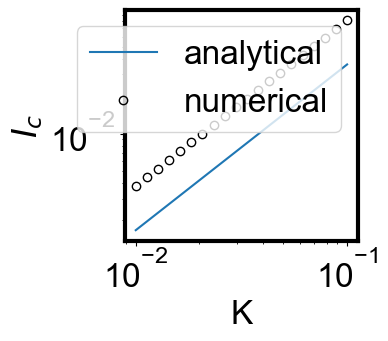

Array([2.26921692, 2.26921692, 2.26921692, 2.26921692, 2.26921692,
       2.26921692, 2.26921692, 2.26921692, 2.26921692, 2.26921692,
       2.26921692, 2.26921692, 2.26921692, 2.26921692, 2.26943054,
       2.26943054, 2.26943054, 2.26943054, 2.26943054, 2.26964417],      dtype=float64)

In [72]:
KD_grid, Ic_grid, models = KD_sweep(state, savedir=savedir, ϵ=0.03)

In [78]:
%matplotlib qt

In [86]:
"""plot"""
color_1 = np.array([94, 45, 144]) / 255
color_2 = np.array([210, 85, 39]) / 255

reds = np.linspace(color_1[0], color_2[0], 5)
greens = np.linspace(color_1[1], color_2[1], 5)
blues = np.linspace(color_1[2], color_2[2], 5)


fig, ax = plt.subplots(figsize=(6, 5.5))
ax.clear()

# load the data, ϵ=1
counter = 0
color = (reds[counter], greens[counter], blues[counter])
with open(
    path_to_data + "/KD_sweep_eps_1.pkl",
    "rb",
) as f:
    KD_sweep_dict = pickle.load(f)
KDs = KD_sweep_dict["KD_grid"]
Ic_wave = KD_sweep_dict["Ic_grid"]

ax.plot(
    KDs,
    Ic_wave,
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=color,
    label="$\epsilon$=1",
)





# # load the data, ϵ=0.05
# counter += 1
# color = (reds[counter], greens[counter], blues[counter])
# with open(
#     path_to_data + "/KD_sweep_eps_0pt05.pkl",
#     "rb",
# ) as f:
#     KD_sweep_dict = pickle.load(f)
# KDs = KD_sweep_dict["KD_grid"]
# Ic_wave = KD_sweep_dict["Ic_grid"]

# ax.plot(
#     KDs,
#     Ic_wave,
#     marker="o",
#     markersize=markersize,
#     markerfacecolor=np.concatenate((sim_color, [0.0])),
#     markeredgewidth=markeredgewidth,
#     linestyle="none",
#     markeredgecolor=color,
#     label="$\epsilon$=0.05",
# )


# load the data, ϵ=0.03
counter += 1
color = (reds[counter], greens[counter], blues[counter])
with open(
    path_to_data + "/KD_sweep_eps_0pt03.pkl",
    "rb",
) as f:
    KD_sweep_dict = pickle.load(f)
KDs = KD_sweep_dict["KD_grid"]
Ic_wave = KD_sweep_dict["Ic_grid"]

ax.plot(
    KDs,
    Ic_wave,
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=color,
    label="$\epsilon$=0.03",
)

# load the data, ϵ=0.01
counter += 1
color = (reds[counter], greens[counter], blues[counter])
with open(
    path_to_data + "/KD_sweep.pkl",
    "rb",
) as f:
    KD_sweep_dict = pickle.load(f)
KDs = KD_sweep_dict["KD_grid"]
Ic_wave = KD_sweep_dict["Ic_grid"]
print(Ic_wave)
hill_coefficient = 4


ax.plot(
    KDs,
    Ic_wave,
    marker="o",
    markersize=markersize,
    markerfacecolor=np.concatenate((sim_color, [0.0])),
    markeredgewidth=markeredgewidth,
    linestyle="none",
    markeredgecolor=color,
    label="$\epsilon$=0.01",
)

KDs_theory = np.logspace(np.log10(np.min(KDs)), np.log10(np.max(KDs)), 1000)
tissue_theory = Ic(KDs_theory, hill_coefficient)
ax.plot(
    KDs_theory,
    tissue_theory,
    "-",
    linewidth=linewidth,
    color=colors["wave"],
    label="analytic",
)

ax.legend(fontsize=fontsize, loc="upper left")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"$I^{wave}_{c}$ (a.u.)", fontsize=fontsize)
ax.set_xlabel(
    "concentration scale \nof positive feedback, $K_D$ (a.u.)", fontsize=fontsize
)
#ax.set_ylim([1e-3, 1e-1])
ax.minorticks_off()
style_axes(ax, fontsize=fontsize)
fig.tight_layout()

[0.01468037 0.0172549  0.02028093 0.02383764 0.02801964 0.0329335
 0.03870913 0.04549763 0.05347959 0.06285842 0.07388205 0.08684367
 0.10207364 0.1199811  0.14103018 0.16576297 0.19484387 0.22903985
 0.26922268 0.3164552 ]


<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
<>:110: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
<>:110: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_6664/881998873.py:33: SyntaxWarning: invalid escape sequence '\e'
  label="$\epsilon$=1",
/tmp/ipykernel_6664/881998873.py:84: SyntaxWarning: invalid escape sequence '\e'
  label="$\epsilon$=0.03",
/tmp/ipykernel_6664/881998873.py:110: SyntaxWarning: invalid escape sequence '\e'
  label="$\epsilon$=0.01",


In [87]:
plt.savefig(r'/home/brandon/Documents/Code/immunowave/plots/2025_11_11_delayed_autoactivation_Ic_vs_KD.pdf')

In [84]:
fig.get_size_inches()

array([6.14, 5.42])

In [51]:
Ic_wave

Array([0.01468037, 0.0172549 , 0.02028093, 0.02383764, 0.02801964,
       0.0329335 , 0.03870913, 0.04549763, 0.05347959, 0.06285842,
       0.07388205, 0.08684367, 0.10207364, 0.1199811 , 0.14103018,
       0.16576297, 0.19484387, 0.22903985, 0.26922268, 0.3164552 ],      dtype=float64)